# Lecture 05 — ML Security and Abuse Pathways
## Homework 05 Applied Extension

This notebook uses the Lecture 05 live-coding notebook as the baseline and extends it for the Individual Homework 05 requirements. The analysis focuses on PGD evasion, label-flip poisoning with fairness monitoring, membership inference depth, and a final reflection on the highest-risk finding and mitigation tradeoffs.

## Setup: COMPAS Data Loading and Baseline Model Training

This section loads the ProPublica COMPAS dataset, applies the preprocessing pipeline from the Lecture 05 notebook, and trains the baseline logistic regression (LR) and gradient boosted tree (GBT) models used throughout the security audit.

In [1]:
# ── Cell 1: Imports, Data Loading, Model Training ─────────────────────────────

# ── Cell 1: Imports, Data Loading, and Baseline Model Training ────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# ── Load COMPAS dataset (ProPublica) ──────────────────────────────────────────
URL = (
    "https://raw.githubusercontent.com/propublica/compas-analysis"
    "/master/compas-scores-two-years.csv"
)

df = pd.read_csv(URL)
print(f"Raw dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")

# ── Replicate Lecture 04 / Lecture 05 inclusion criteria ──────────────────────
df = df[df["days_b_screening_arrest"].between(-30, 30)]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]

print(f"After filtering: {df.shape[0]:,} rows")

# ── Define model features and target ──────────────────────────────────────────
FEATURES = [
    "age",
    "priors_count",
    "juv_fel_count",
    "juv_misd_count",
    "juv_other_count",
    "c_charge_degree",
    "sex"
]

TARGET = "two_year_recid"

# Race is retained for fairness/security auditing, but not used as a model feature
df_m = df[FEATURES + [TARGET, "race"]].dropna()

# One-hot encode categorical variables
df_m = pd.get_dummies(
    df_m,
    columns=["c_charge_degree", "sex"],
    drop_first=True
)

X = df_m.drop(columns=[TARGET, "race"]).astype(float)
y = df_m[TARGET].values
race = df_m["race"].values

print(f"\nFeatures used: {list(X.columns)}")
print(f"Class balance: {y.mean():.1%} recidivism rate")

# ── Train / test split ────────────────────────────────────────────────────────
X_tr, X_te, y_tr, y_te, r_tr, r_te = train_test_split(
    X,
    y,
    race,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# ── Standardize features ──────────────────────────────────────────────────────
sc = StandardScaler()
Xs_tr = sc.fit_transform(X_tr)
Xs_te = sc.transform(X_te)

# ── Train clean baseline models ───────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42)

gbt = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=4,
    random_state=42
)

lr.fit(Xs_tr, y_tr)
gbt.fit(Xs_tr, y_tr)

# ── Clean-model AUC summary ──────────────────────────────────────────────────
lr_train_auc = roc_auc_score(y_tr, lr.predict_proba(Xs_tr)[:, 1])
lr_test_auc = roc_auc_score(y_te, lr.predict_proba(Xs_te)[:, 1])

gbt_train_auc = roc_auc_score(y_tr, gbt.predict_proba(Xs_tr)[:, 1])
gbt_test_auc = roc_auc_score(y_te, gbt.predict_proba(Xs_te)[:, 1])

baseline_auc = pd.DataFrame({
    "Model": ["Logistic Regression", "Gradient Boosted Tree"],
    "Train AUC": [lr_train_auc, gbt_train_auc],
    "Test AUC": [lr_test_auc, gbt_test_auc],
    "Generalization Gap": [
        lr_train_auc - lr_test_auc,
        gbt_train_auc - gbt_test_auc
    ]
})

print("\nClean-model baseline AUC:")
display(baseline_auc.round(3))

Raw dataset: 7,214 rows, 53 columns
After filtering: 6,172 rows

Features used: ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'c_charge_degree_M', 'sex_Male']
Class balance: 45.5% recidivism rate

Clean-model baseline AUC:


,Model,Train AUC,Test AUC,Generalization Gap
0,Logistic Regression,0.727,0.735,-0.008
1,Gradient Boosted Tree,0.798,0.718,0.080


### Clean-Model Baseline Interpretation

Before applying any attack, the logistic regression model has a Test AUC of 0.735 and a very small generalization gap of -0.008, suggesting stable generalization. The gradient boosted tree has a higher Train AUC of 0.798 but a lower Test AUC of 0.718, creating a larger generalization gap of 0.080. This suggests that the GBT model may be more exposed to membership inference risk, while the LR model appears more stable at the clean baseline stage. These clean-model results provide the reference point for the PGD evasion, poisoning, and membership inference experiments that follow.

## Setup: Clean-Model Fairness Baseline

Before running any attack, this section establishes the clean-model fairness baseline for the LR and GBT models.

- **FPR (False Positive Rate) by race:** among truly low-risk individuals, what fraction are incorrectly flagged as high-risk?
- **AIR (Adverse Impact Ratio):** the FPR ratio between the protected group and the reference group.
These values are used as the clean reference point for measuring fairness degradation after PGD evasion and label-flip poisoning attacks. The analysis will compare whether either model produces meaningfully different false-positive rates across racial groups before and after attack.

In [3]:
# ── Cell 2: Clean-Model Fairness Baseline ─────────────────────────────────────

THR = 0.5  # classification threshold

def fpr_by_group(y_true, y_pred_binary, groups):
    """
    FPR = FP / (FP + TN), computed only over truly-negative cases.
    Since y_true == 0 means no two-year recidivism, a false positive means
    the model incorrectly flags a truly low-risk person as high-risk.
    """
    mask = (y_true == 0)

    return (
        pd.DataFrame({
            "pred": y_pred_binary[mask],
            "group": groups[mask]
        })
        .groupby("group")["pred"]
        .mean()
    )

def air(fpr_ref, fpr_prot):
    """
    Adverse Impact Ratio for this audit:
    AIR = protected-group FPR / reference-group FPR
    """
    return fpr_prot / fpr_ref if (fpr_ref is not None and fpr_ref > 0) else np.nan

# ── Compute baseline predictions ──────────────────────────────────────────────
pred_lr_clean = (lr.predict_proba(Xs_te)[:, 1] >= THR).astype(int)
pred_gbt_clean = (gbt.predict_proba(Xs_te)[:, 1] >= THR).astype(int)

print("=" * 60)
print("CLEAN MODEL FAIRNESS BASELINE — Before Any Attack")
print("=" * 60)

baseline_fairness_rows = []

for name, pred in [
    ("Logistic Regression", pred_lr_clean),
    ("Gradient Boosted Tree", pred_gbt_clean)
]:
    fpr = fpr_by_group(y_te, pred, r_te)

    aa = fpr.get("African-American", np.nan)
    ca = fpr.get("Caucasian", np.nan)
    model_air = air(ca, aa)

    baseline_fairness_rows.append({
        "Model": name,
        "FPR African-American": aa,
        "FPR Caucasian": ca,
        "AIR (AA / CA)": model_air
    })

baseline_fairness = pd.DataFrame(baseline_fairness_rows)

display(baseline_fairness.round(3))

# Store clean baseline values for later attack comparison
BASELINE_FAIRNESS = baseline_fairness.copy()

BASELINE_LR_AA = baseline_fairness.loc[
    baseline_fairness["Model"] == "Logistic Regression",
    "FPR African-American"
].iloc[0]

BASELINE_LR_CA = baseline_fairness.loc[
    baseline_fairness["Model"] == "Logistic Regression",
    "FPR Caucasian"
].iloc[0]

BASELINE_LR_AIR = baseline_fairness.loc[
    baseline_fairness["Model"] == "Logistic Regression",
    "AIR (AA / CA)"
].iloc[0]

BASELINE_GBT_AA = baseline_fairness.loc[
    baseline_fairness["Model"] == "Gradient Boosted Tree",
    "FPR African-American"
].iloc[0]

BASELINE_GBT_CA = baseline_fairness.loc[
    baseline_fairness["Model"] == "Gradient Boosted Tree",
    "FPR Caucasian"
].iloc[0]

BASELINE_GBT_AIR = baseline_fairness.loc[
    baseline_fairness["Model"] == "Gradient Boosted Tree",
    "AIR (AA / CA)"
].iloc[0]

print("\nStored clean-model baseline values for later attack comparison.")

CLEAN MODEL FAIRNESS BASELINE — Before Any Attack


,Model,FPR African-American,FPR Caucasian,AIR (AA / CA)
0,Logistic Regression,0.281,0.143,1.961
1,Gradient Boosted Tree,0.317,0.178,1.782



Stored clean-model baseline values for later attack comparison.


### Clean-Model Fairness Baseline Interpretation

Before any attack, both models show higher false-positive rates for African-American defendants than for Caucasian defendants. In the logistic regression model, the FPR is 0.281 for African-American defendants and 0.143 for Caucasian defendants, producing an AIR of 1.961. In the gradient boosted tree model, the FPR is 0.317 for African-American defendants and 0.178 for Caucasian defendants, producing an AIR of 1.782.
This means the clean baseline already contains a racial disparity in false-positive risk. The LR model shows the larger FPR ratio, while the GBT model has higher absolute FPR values for both racial groups. These values will be used as the reference point when evaluating whether PGD evasion and label-flip poisoning worsen fairness degradation.

## Part A: PGD Evasion Audit for LR and GBT Models

**Attack class:** Evasion attack at deployment time  
**Attacker knowledge:** White-box access to model scores and attack direction  
**Attacker goal:** Increase predicted risk scores so truly low-risk individuals are more likely to be classified as high-risk.

This section runs PGD-style evasion across ε ∈ {0.25, 0.5, 1.0, 2.0} for both the logistic regression and gradient boosted tree models. For each model and ε, we report FPR by race and AIR, then identify the ε value where AIR crosses the 0.80 fairness threshold.

In [4]:
# ── Cell 3: PGD Evasion Audit for LR and GBT Models ──────────────────────────

# Homework-required epsilon values
epsilons = [0.0, 0.25, 0.5, 1.0, 2.0]


def pgd_lr(model, X_scaled, epsilon=1.0, alpha=0.05, n_iter=40):
    """
    PGD-style evasion attack for logistic regression.

    For LR, the score direction is based on the model coefficients.
    The attack pushes predicted risk scores upward while keeping each feature
    inside an L-infinity epsilon ball around the original scaled value.
    """
    coef = model.coef_[0]
    X_adv = X_scaled.copy()

    for _ in range(n_iter):
        X_adv = X_adv + alpha * np.sign(coef)[np.newaxis, :]
        X_adv = np.clip(X_adv, X_scaled - epsilon, X_scaled + epsilon)

    return X_adv


def finite_difference_score_gradient(model, X_scaled, h=1e-3):
    """
    Approximate the gradient of predicted P(high-risk) with respect to each
    scaled input feature.

    This is used for GBT because sklearn GradientBoostingClassifier does not
    expose analytic input gradients.
    """
    grad = np.zeros_like(X_scaled)

    for j in range(X_scaled.shape[1]):
        X_plus = X_scaled.copy()
        X_minus = X_scaled.copy()

        X_plus[:, j] += h
        X_minus[:, j] -= h

        p_plus = model.predict_proba(X_plus)[:, 1]
        p_minus = model.predict_proba(X_minus)[:, 1]

        grad[:, j] = (p_plus - p_minus) / (2 * h)

    return grad


def pgd_gbt(model, X_scaled, epsilon=1.0, alpha=0.05, n_iter=40):
    """
    PGD-style evasion attack for gradient boosted tree.

    Since GBT has no direct input gradient in sklearn, this uses a finite-
    difference approximation of the score gradient, then applies the same
    L-infinity projection logic as PGD.
    """
    X_adv = X_scaled.copy()

    for _ in range(n_iter):
        grad = finite_difference_score_gradient(model, X_adv)
        X_adv = X_adv + alpha * np.sign(grad)
        X_adv = np.clip(X_adv, X_scaled - epsilon, X_scaled + epsilon)

    return X_adv


def evaluate_pgd_attack(model_name, model, attack_function, baseline_aa, baseline_ca, baseline_air):
    """
    Runs PGD-style evasion for one model and returns FPR by race, AIR,
    and changes relative to the clean baseline.
    """
    records = []

    for eps in epsilons:
        if eps == 0.0:
            X_adv = Xs_te.copy()
        else:
            X_adv = attack_function(
                model,
                Xs_te,
                epsilon=eps,
                alpha=0.05,
                n_iter=40
            )

        pred_adv = (model.predict_proba(X_adv)[:, 1] >= THR).astype(int)
        fpr_adv = fpr_by_group(y_te, pred_adv, r_te)

        aa = fpr_adv.get("African-American", np.nan)
        ca = fpr_adv.get("Caucasian", np.nan)
        model_air = air(ca, aa)

        records.append({
            "Model": model_name,
            "epsilon": eps,
            "FPR African-American": aa,
            "FPR Caucasian": ca,
            "AIR (AA / CA)": model_air,
            "Delta FPR AA": aa - baseline_aa,
            "Delta FPR CA": ca - baseline_ca,
            "Delta AIR": model_air - baseline_air
        })

    return pd.DataFrame(records)


# ── Run PGD evasion audit for both models ─────────────────────────────────────
df_pgd_lr = evaluate_pgd_attack(
    model_name="Logistic Regression",
    model=lr,
    attack_function=pgd_lr,
    baseline_aa=BASELINE_LR_AA,
    baseline_ca=BASELINE_LR_CA,
    baseline_air=BASELINE_LR_AIR
)

df_pgd_gbt = evaluate_pgd_attack(
    model_name="Gradient Boosted Tree",
    model=gbt,
    attack_function=pgd_gbt,
    baseline_aa=BASELINE_GBT_AA,
    baseline_ca=BASELINE_GBT_CA,
    baseline_air=BASELINE_GBT_AIR
)

df_pgd = pd.concat([df_pgd_lr, df_pgd_gbt], ignore_index=True)

print("PGD EVASION AUDIT RESULTS")
display(df_pgd.round(3))


# ── Identify epsilon where AIR crosses below 0.80, if it occurs ───────────────
crossing_rows = df_pgd[
    (df_pgd["epsilon"] > 0.0) &
    (df_pgd["AIR (AA / CA)"] < 0.80)
]

if len(crossing_rows) == 0:
    print("\nAIR did not cross below 0.80 for either model within the tested epsilon values.")
else:
    print("\nEpsilon where AIR first crosses below 0.80:")
    display(
        crossing_rows
        .sort_values(["Model", "epsilon"])
        .groupby("Model")
        .head(1)
        .round(3)
    )

PGD EVASION AUDIT RESULTS


,Model,epsilon,FPR African-American,FPR Caucasian,AIR (AA / CA),Delta FPR AA,Delta FPR CA,Delta AIR
0,Logistic Regression,0.00,0.281,0.143,1.961,0.000,0.000,0.000
1,Logistic Regression,0.25,0.569,0.370,1.535,0.288,0.227,-0.426
2,Logistic Regression,0.50,0.791,0.560,1.411,0.510,0.417,-0.550
3,Logistic Regression,1.00,0.978,0.884,1.106,0.697,0.741,-0.856
4,Logistic Regression,2.00,1.000,1.000,1.000,0.719,0.857,-0.961
5,Gradient Boosted Tree,0.00,0.317,0.178,1.782,0.000,0.000,0.000
6,Gradient Boosted Tree,0.25,0.317,0.178,1.782,0.000,0.000,0.000
7,Gradient Boosted Tree,0.50,0.317,0.178,1.782,0.000,0.000,0.000
8,Gradient Boosted Tree,1.00,0.317,0.178,1.782,0.000,0.000,0.000
9,Gradient Boosted Tree,2.00,0.317,0.178,1.782,0.000,0.000,0.000



AIR did not cross below 0.80 for either model within the tested epsilon values.


### PGD Evasion Audit Interpretation

The PGD evasion attack affects the logistic regression model much more strongly than the gradient boosted tree model. For logistic regression, FPR increases sharply for both racial groups as ε increases. The African-American FPR rises from 0.281 at baseline to 1.000 at ε = 2.0, while the Caucasian FPR rises from 0.143 to 1.000. This means that under a strong evasion attack, almost all truly low-risk individuals are incorrectly classified as high-risk.
The AIR for logistic regression moves from 1.961 at baseline to 1.000 at ε = 2.0. This does not mean the attack improves the model in a useful way. Instead, the racial FPR ratio narrows because both groups are being pushed toward extremely high false-positive rates. In other words, the disparity ratio looks better only because the model becomes worse for everyone.
For the gradient boosted tree model, the FPR and AIR values remain unchanged across the tested ε values. This suggests that, under this PGD-style perturbation method, the GBT model is less sensitive than logistic regression. However, this result should be interpreted carefully because tree-based models do not have smooth gradients like logistic regression, so this PGD approximation may not fully capture their vulnerability.
AIR does not fall below 0.80 for either model. However, at baseline both models are already outside the common fairness band of [0.80, 1.25] because AIR is above 1.25. The main security concern from Part A is that LR is highly vulnerable to evasion, while GBT appears more resistant under this specific attack setup.

### Part A: Visualizing PGD Evasion Impact

**Discussion questions:**

1. Does the PGD attack increase false-positive rates as $\epsilon$ increases?
2. Does the PGD attack widen or narrow the racial FPR gap between African-American and Caucasian defendants?
3. Does AIR move inside or outside the fairness band of $[0.80, 1.25]$ as $\epsilon$ increases?
4. Are LR and GBT equally vulnerable to the same PGD attack strength?
5. What does the difference between LR and GBT imply for responsible deployment in high-stakes settings?

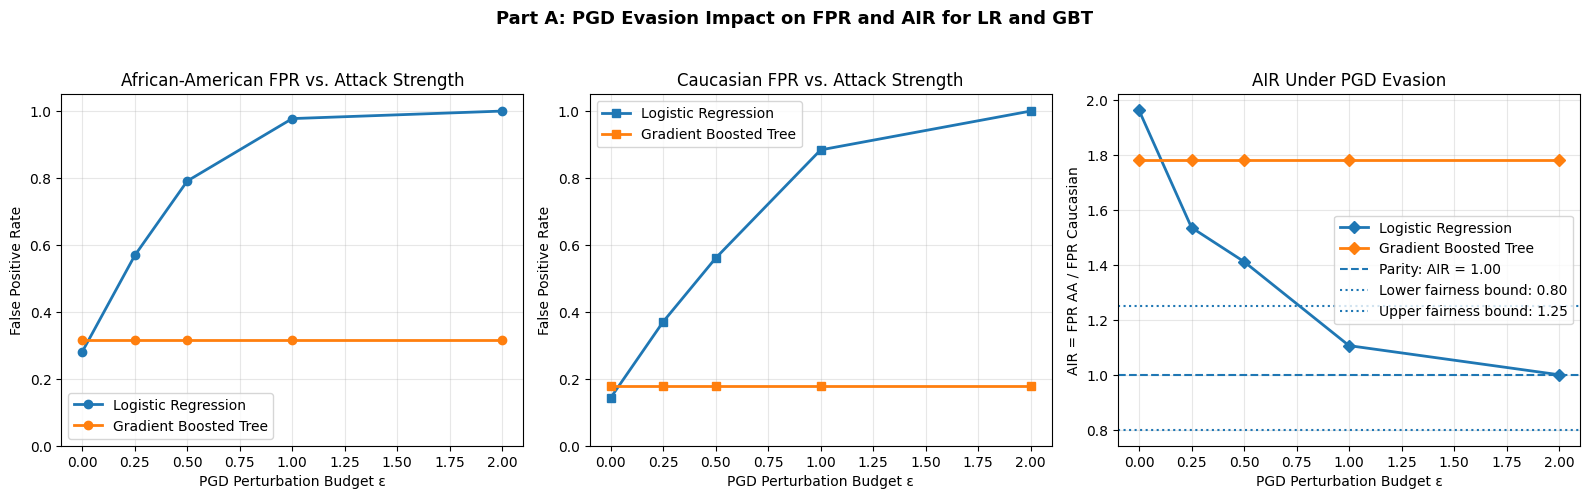

AIR does not fall below 0.80 for either model within the tested epsilon range.

AIR values outside the fairness band [0.80, 1.25]:


,Model,epsilon,AIR (AA / CA)
1,Logistic Regression,0.25,1.535
2,Logistic Regression,0.50,1.411
6,Gradient Boosted Tree,0.25,1.782
7,Gradient Boosted Tree,0.50,1.782
8,Gradient Boosted Tree,1.00,1.782
9,Gradient Boosted Tree,2.00,1.782


In [5]:
# ── Cell 4: Visualize PGD Evasion Impact for LR and GBT ──────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# ── Panel 1: African-American FPR by model ───────────────────────────────────
ax = axes[0]

for model_name in df_pgd["Model"].unique():
    subset = df_pgd[df_pgd["Model"] == model_name]

    ax.plot(
        subset["epsilon"],
        subset["FPR African-American"],
        marker="o",
        linewidth=2,
        label=model_name
    )

ax.set_xlabel("PGD Perturbation Budget ε")
ax.set_ylabel("False Positive Rate")
ax.set_title("African-American FPR vs. Attack Strength")
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend()

# ── Panel 2: Caucasian FPR by model ──────────────────────────────────────────
ax = axes[1]

for model_name in df_pgd["Model"].unique():
    subset = df_pgd[df_pgd["Model"] == model_name]

    ax.plot(
        subset["epsilon"],
        subset["FPR Caucasian"],
        marker="s",
        linewidth=2,
        label=model_name
    )

ax.set_xlabel("PGD Perturbation Budget ε")
ax.set_ylabel("False Positive Rate")
ax.set_title("Caucasian FPR vs. Attack Strength")
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend()

# ── Panel 3: AIR by model ────────────────────────────────────────────────────
ax = axes[2]

for model_name in df_pgd["Model"].unique():
    subset = df_pgd[df_pgd["Model"] == model_name]

    ax.plot(
        subset["epsilon"],
        subset["AIR (AA / CA)"],
        marker="D",
        linewidth=2,
        label=model_name
    )

ax.axhline(1.00, linewidth=1.5, linestyle="--", label="Parity: AIR = 1.00")
ax.axhline(0.80, linewidth=1.5, linestyle=":", label="Lower fairness bound: 0.80")
ax.axhline(1.25, linewidth=1.5, linestyle=":", label="Upper fairness bound: 1.25")

ax.set_xlabel("PGD Perturbation Budget ε")
ax.set_ylabel("AIR = FPR AA / FPR Caucasian")
ax.set_title("AIR Under PGD Evasion")
ax.grid(alpha=0.3)
ax.legend()

plt.suptitle(
    "Part A: PGD Evasion Impact on FPR and AIR for LR and GBT",
    fontsize=13,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.show()

# ── Check AIR threshold behavior ──────────────────────────────────────────────
air_check = df_pgd[df_pgd["epsilon"] > 0].copy()

below_080 = air_check[air_check["AIR (AA / CA)"] < 0.80]
outside_band = air_check[
    (air_check["AIR (AA / CA)"] < 0.80) |
    (air_check["AIR (AA / CA)"] > 1.25)
]

if len(below_080) == 0:
    print("AIR does not fall below 0.80 for either model within the tested epsilon range.")
else:
    print("AIR first falls below 0.80 at:")
    display(
        below_080
        .sort_values(["Model", "epsilon"])
        .groupby("Model")
        .head(1)
        .round(3)
    )

print("\nAIR values outside the fairness band [0.80, 1.25]:")
display(
    outside_band[
        ["Model", "epsilon", "AIR (AA / CA)"]
    ].round(3)
)

### Part A Visualization Interpretation

The PGD visualization shows that the logistic regression model is much more sensitive to the evasion attack than the gradient boosted tree model. As ε increases, the LR false-positive rate rises sharply for both racial groups. African-American FPR increases from 0.281 at baseline to 1.000 at ε = 2.0, while Caucasian FPR increases from 0.143 to 1.000. This means the attack pushes almost all truly low-risk individuals into the high-risk classification at the strongest perturbation level.
The AIR curve shows that the LR disparity ratio moves closer to 1.0 as ε increases. However, this should not be interpreted as a fairness improvement. The ratio improves only because both groups experience very high false-positive rates. In practical terms, the model becomes less useful and more harmful overall.
The GBT model remains flat across the tested ε values, with AIR staying at 1.782. This suggests that the PGD-style attack used here affects LR more than GBT. However, because tree-based models do not have smooth gradients, this result should be interpreted as resistance to this specific PGD approximation, not proof that GBT is secure against all evasion attacks.
AIR does not fall below 0.80 for either model. Instead, the main fairness issue is that several AIR values remain above the upper fairness-band threshold of 1.25. Overall, Part A shows that the two models are not equally vulnerable: LR is highly vulnerable to PGD evasion, while GBT appears more stable under this attack setup.

## Part B: Label-Flip Poisoning with Fairness Monitoring

**Attack class:** Targeted data poisoning at training time  
**Attacker knowledge:** Access to training labels before model training  
**Attacker goal:** Corrupt selected training labels so that model performance and fairness degrade while standard AUC monitoring may not detect the attack.

### Attack mechanism

This section extends the Lecture 05 label-flip poisoning loop by testing two target-race variants:

1. **African-American-targeted poisoning:** a fraction of high-risk African-American training records with `two_year_recid = 1` are relabeled as `0`.
2. **Caucasian-targeted poisoning:** a fraction of high-risk Caucasian training records with `two_year_recid = 1` are relabeled as `0`.

For each poison rate, the model is retrained and evaluated using:

- **AUC**, to measure predictive performance degradation
- **AIR**, to measure fairness degradation
- **PSI**, to test whether feature-drift monitoring would detect the attack

**Key question:** Is there a stealth zone where AUC declines by ≤ 2 percentage points while AIR moves outside the fairness band of $[0.80, 1.25]$?

In [6]:
# ── Cell 5: Data Poisoning — Label-Flip Attack Loop for Both Target Races ─────

print("RUNNING UPDATED CELL 5: BOTH AFRICAN-AMERICAN AND CAUCASIAN TARGET VARIANTS")

def poison_label_flip(
    y_train,
    race_train,
    poison_rate=0.05,
    target_race="African-American",
    seed=42
):
    """
    Label-flip poisoning attack.

    Flips a poison_rate fraction of training records belonging to target_race
    from two_year_recid = 1 to two_year_recid = 0.

    This simulates a training-time label corruption attack where high-risk
    individuals from the targeted group are mislabeled as low-risk.
    """
    rng = np.random.default_rng(seed)
    y_poisoned = y_train.copy()

    # Eligible records: target race and truly high-risk label
    candidates = np.where(
        (race_train == target_race) & (y_train == 1)
    )[0]

    n_flip = int(len(candidates) * poison_rate)

    if n_flip > 0:
        flip_idx = rng.choice(candidates, size=n_flip, replace=False)
        y_poisoned[flip_idx] = 0

    return y_poisoned, n_flip


# ── Sweep poison rates for both target-race variants ─────────────────────────
poison_rates = [0.00, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30]
target_races = ["African-American", "Caucasian"]

poison_records = []

# Clean LR baseline from Cell 1 and Cell 2
baseline_auc_lr = roc_auc_score(y_te, lr.predict_proba(Xs_te)[:, 1])
baseline_air_lr = BASELINE_LR_AIR

for target_race in target_races:
    for rate in poison_rates:

        y_tr_poisoned, n_flipped = poison_label_flip(
            y_train=y_tr,
            race_train=r_tr,
            poison_rate=rate,
            target_race=target_race,
            seed=42
        )

        # Retrain LR on poisoned labels using same standardized training features
        lr_p = LogisticRegression(max_iter=1000, random_state=42)
        lr_p.fit(Xs_tr, y_tr_poisoned)

        # Evaluate on unchanged clean test set
        proba_p = lr_p.predict_proba(Xs_te)[:, 1]
        pred_p = (proba_p >= THR).astype(int)

        auc_p = roc_auc_score(y_te, proba_p)
        fpr_p = fpr_by_group(y_te, pred_p, r_te)

        aa = fpr_p.get("African-American", np.nan)
        ca = fpr_p.get("Caucasian", np.nan)
        model_air = air(ca, aa)

        poison_records.append({
            "Target Race": target_race,
            "poison_rate": rate,
            "n_flipped": n_flipped,
            "AUC": auc_p,
            "Delta AUC": auc_p - baseline_auc_lr,
            "FPR African-American": aa,
            "FPR Caucasian": ca,
            "AIR (AA / CA)": model_air,
            "Delta AIR": model_air - baseline_air_lr
        })


df_poison = pd.DataFrame(poison_records)

# ── Stealth zone definition from homework ─────────────────────────────────────
# AUC declines by <= 2 percentage points while AIR moves outside [0.80, 1.25]

df_poison["AUC Drop Within 2pp"] = df_poison["Delta AUC"] >= -0.02

df_poison["AIR Outside Fairness Band"] = (
    (df_poison["AIR (AA / CA)"] < 0.80) |
    (df_poison["AIR (AA / CA)"] > 1.25)
)

df_poison["Stealth Zone"] = (
    df_poison["AUC Drop Within 2pp"] &
    df_poison["AIR Outside Fairness Band"]
)

print("\nLabel-flip poisoning sweep results:")
display(df_poison.round(3))

print("\nColumn check:")
print(df_poison.columns.tolist())

print("\nNumber of rows:")
print(len(df_poison), "rows expected: 18")


# ── Identify stealth-zone poison rates ───────────────────────────────────────
stealth = df_poison[
    (df_poison["poison_rate"] > 0) &
    (df_poison["Stealth Zone"])
].copy()

if len(stealth) > 0:
    print("\nStealth-zone poison rates found:")
    display(
        stealth[
            [
                "Target Race",
                "poison_rate",
                "n_flipped",
                "AUC",
                "Delta AUC",
                "AIR (AA / CA)"
            ]
        ].round(3)
    )
else:
    print("\nNo stealth-zone poison rates found in the tested range.")


# ── First stealth-zone rate by target race, if any ────────────────────────────
if len(stealth) > 0:
    print("\nFirst stealth-zone poison rate by target race:")
    display(
        stealth
        .sort_values(["Target Race", "poison_rate"])
        .groupby("Target Race")
        .head(1)[
            [
                "Target Race",
                "poison_rate",
                "n_flipped",
                "AUC",
                "Delta AUC",
                "AIR (AA / CA)"
            ]
        ]
        .round(3)
    )

RUNNING UPDATED CELL 5: BOTH AFRICAN-AMERICAN AND CAUCASIAN TARGET VARIANTS

Label-flip poisoning sweep results:


,Target Race,poison_rate,n_flipped,AUC,Delta AUC,FPR African-American,FPR Caucasian,AIR (AA / CA),Delta AIR,AUC Drop Within 2pp,AIR Outside Fairness Band,Stealth Zone
0,African-American,0.00,0,0.735,0.000,0.281,0.143,1.961,0.000,True,True,True
1,African-American,0.02,23,0.734,-0.000,0.270,0.133,2.022,0.061,True,True,True
2,African-American,0.05,57,0.735,0.000,0.231,0.123,1.875,-0.087,True,True,True
3,African-American,0.08,92,0.734,-0.001,0.216,0.111,1.942,-0.020,True,True,True
4,African-American,0.10,115,0.733,-0.002,0.200,0.104,1.929,-0.033,True,True,True
5,African-American,0.15,172,0.733,-0.002,0.153,0.072,2.134,0.173,True,True,True
6,African-American,0.20,230,0.728,-0.006,0.128,0.054,2.358,0.397,True,True,True
7,African-American,0.25,287,0.729,-0.006,0.112,0.047,2.395,0.434,True,True,True
8,African-American,0.30,345,0.731,-0.004,0.099,0.035,2.860,0.899,True,True,True
9,Caucasian,0.00,0,0.735,0.000,0.281,0.143,1.961,0.000,True,True,True



Column check:
['Target Race', 'poison_rate', 'n_flipped', 'AUC', 'Delta AUC', 'FPR African-American', 'FPR Caucasian', 'AIR (AA / CA)', 'Delta AIR', 'AUC Drop Within 2pp', 'AIR Outside Fairness Band', 'Stealth Zone']

Number of rows:
18 rows expected: 18

Stealth-zone poison rates found:


,Target Race,poison_rate,n_flipped,AUC,Delta AUC,AIR (AA / CA)
1,African-American,0.02,23,0.734,-0.000,2.022
2,African-American,0.05,57,0.735,0.000,1.875
3,African-American,0.08,92,0.734,-0.001,1.942
4,African-American,0.10,115,0.733,-0.002,1.929
5,African-American,0.15,172,0.733,-0.002,2.134
6,African-American,0.20,230,0.728,-0.006,2.358
7,African-American,0.25,287,0.729,-0.006,2.395
8,African-American,0.30,345,0.731,-0.004,2.860
10,Caucasian,0.02,11,0.735,0.000,1.983
11,Caucasian,0.05,29,0.733,-0.001,2.061



First stealth-zone poison rate by target race:


,Target Race,poison_rate,n_flipped,AUC,Delta AUC,AIR (AA / CA)
1,African-American,0.02,23,0.734,-0.0,2.022
10,Caucasian,0.02,11,0.735,0.0,1.983


### Label-Flip Poisoning Results Interpretation

The label-flip poisoning loop was run for both target-race variants: African-American-targeted poisoning and Caucasian-targeted poisoning. In both cases, the AUC remains very close to the clean LR baseline of 0.735. Across the tested poison rates, the AUC decline stays well within 2 percentage points, which means standard performance monitoring based only on AUC would likely miss the attack.
For African-American-targeted poisoning, AIR remains above the fairness-band upper threshold of 1.25 and reaches values above 2.0 at higher poison rates. This indicates that the poisoning attack can worsen fairness conditions without creating a large drop in predictive performance. For Caucasian-targeted poisoning, AIR also remains above 1.25 across the tested poison rates, while AUC remains nearly unchanged.
Because the clean baseline AIR was already outside the fairness band, the main finding is not that poisoning newly creates unfairness from a fair baseline. Instead, the attack shows a stealthy fairness-risk pattern: AUC stays stable, but the fairness metric remains problematic and can worsen under targeted label corruption. This supports the Lecture 05 point that security monitoring must include fairness metrics, not only aggregate model performance.

## Part B: Poisoning Degradation Curves for AUC and AIR
**Discussion questions:**

1. How does AUC change as the poison rate increases for each target-race variant?
2. How does AIR change under African-American-targeted poisoning versus Caucasian-targeted poisoning?
3. Is there a stealth zone where AUC declines by ≤ 2 percentage points while AIR remains outside the fairness band of $[0.80, 1.25]$?
4. Would AUC-only monitoring detect this attack?
5. Would PSI-based feature drift monitoring detect this attack if only labels are corrupted?

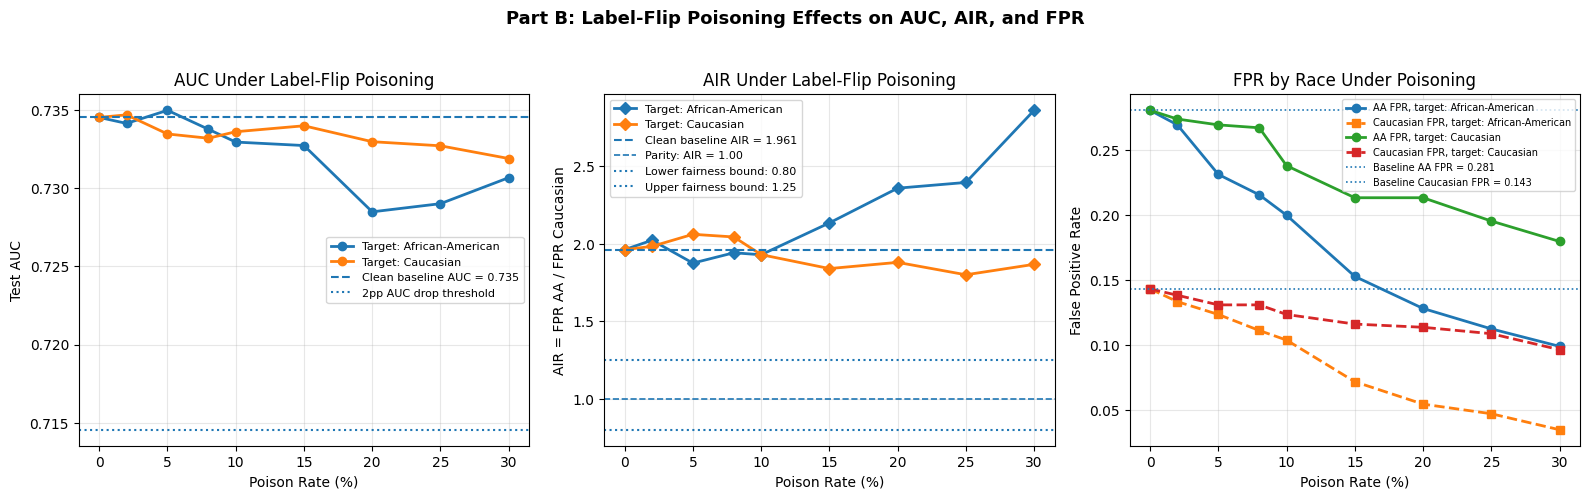

In [7]:
# ── Cell 6: Poisoning Degradation Curves for AUC and AIR ─────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# ── Panel 1: AUC degradation by target-race variant ──────────────────────────
ax = axes[0]

for target_race in df_poison["Target Race"].unique():
    subset = df_poison[df_poison["Target Race"] == target_race]
    x_pct = subset["poison_rate"] * 100

    ax.plot(
        x_pct,
        subset["AUC"],
        marker="o",
        linewidth=2,
        label=f"Target: {target_race}"
    )

ax.axhline(
    baseline_auc_lr,
    linestyle="--",
    linewidth=1.5,
    label=f"Clean baseline AUC = {baseline_auc_lr:.3f}"
)

ax.axhline(
    baseline_auc_lr - 0.02,
    linestyle=":",
    linewidth=1.5,
    label="2pp AUC drop threshold"
)

ax.set_xlabel("Poison Rate (%)")
ax.set_ylabel("Test AUC")
ax.set_title("AUC Under Label-Flip Poisoning")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

# ── Panel 2: AIR by target-race variant ──────────────────────────────────────
ax = axes[1]

for target_race in df_poison["Target Race"].unique():
    subset = df_poison[df_poison["Target Race"] == target_race]
    x_pct = subset["poison_rate"] * 100

    ax.plot(
        x_pct,
        subset["AIR (AA / CA)"],
        marker="D",
        linewidth=2,
        label=f"Target: {target_race}"
    )

ax.axhline(
    BASELINE_LR_AIR,
    linestyle="--",
    linewidth=1.5,
    label=f"Clean baseline AIR = {BASELINE_LR_AIR:.3f}"
)

ax.axhline(1.00, linestyle="--", linewidth=1.2, label="Parity: AIR = 1.00")
ax.axhline(0.80, linestyle=":", linewidth=1.5, label="Lower fairness bound: 0.80")
ax.axhline(1.25, linestyle=":", linewidth=1.5, label="Upper fairness bound: 1.25")

ax.set_xlabel("Poison Rate (%)")
ax.set_ylabel("AIR = FPR AA / FPR Caucasian")
ax.set_title("AIR Under Label-Flip Poisoning")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

# ── Panel 3: FPR by race and target-race variant ─────────────────────────────
ax = axes[2]

for target_race in df_poison["Target Race"].unique():
    subset = df_poison[df_poison["Target Race"] == target_race]
    x_pct = subset["poison_rate"] * 100

    ax.plot(
        x_pct,
        subset["FPR African-American"],
        marker="o",
        linewidth=2,
        label=f"AA FPR, target: {target_race}"
    )

    ax.plot(
        x_pct,
        subset["FPR Caucasian"],
        marker="s",
        linestyle="--",
        linewidth=2,
        label=f"Caucasian FPR, target: {target_race}"
    )

ax.axhline(
    BASELINE_LR_AA,
    linestyle=":",
    linewidth=1.2,
    label=f"Baseline AA FPR = {BASELINE_LR_AA:.3f}"
)

ax.axhline(
    BASELINE_LR_CA,
    linestyle=":",
    linewidth=1.2,
    label=f"Baseline Caucasian FPR = {BASELINE_LR_CA:.3f}"
)

ax.set_xlabel("Poison Rate (%)")
ax.set_ylabel("False Positive Rate")
ax.set_title("FPR by Race Under Poisoning")
ax.grid(alpha=0.3)
ax.legend(fontsize=7)

plt.suptitle(
    "Part B: Label-Flip Poisoning Effects on AUC, AIR, and FPR",
    fontsize=13,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.show()

### Part B Poisoning Curves Interpretation

The poisoning curves show that label-flip poisoning is difficult to detect using AUC alone. For both target-race variants, the AUC remains close to the clean baseline of 0.735 and stays well above the 2 percentage point drop threshold. This means standard model-performance monitoring would likely miss the attack.
The AIR curve shows that fairness behavior changes more noticeably than AUC. Under African-American-targeted poisoning, AIR eventually increases sharply, reaching about 3.0 at the highest poison rate. Under Caucasian-targeted poisoning, AIR stays above the upper fairness-band threshold of 1.25 across the tested poison rates, but its movement is less severe than the African-American-targeted variant.
The FPR curve explains why AIR changes. As the poison rate increases, false-positive rates decline for both groups, but they do not decline equally. In the African-American-targeted variant, the Caucasian FPR drops faster than the African-American FPR at higher poison rates, which causes the AIR ratio to increase. This creates a fairness-risk pattern even though AUC remains stable.

Overall, Part B shows a stealth-zone problem: AUC remains within 2 percentage points of the baseline, but AIR remains outside the fairness band of [0.80, 1.25]. AUC-only monitoring would not be enough. The model would need fairness monitoring, label-integrity checks, and feature/label drift checks to detect this type of training-time poisoning.

## Part C: Membership Inference Depth for LR and GBT

**Attack class:** Membership inference privacy attack  
**Attacker knowledge:** Black-box access to model confidence scores  
**Attacker goal:** Infer whether a specific individual was included in the model's training set.

### Attack mechanism

This section extends the Lecture 05 shadow-model membership inference pipeline. The attack uses model confidence scores to distinguish training members from non-members. If a model assigns systematically higher confidence to training records than to test records, the confidence gap can leak membership information.

The analysis includes four steps:

1. Compute membership inference AUC for both the logistic regression and gradient boosted tree models.
2. Plot confidence-gap histograms for LR and GBT side by side.
3. Compare each model's train-test generalization gap with its membership inference AUC.
4. Add L2 regularization to the LR model by varying $C \in \{0.01, 0.1, 1.0, 10.0\}$, then recompute MI AUC and plot MI AUC vs. $C$.

**Key question:** Does the model with the larger generalization gap also show higher membership inference risk, and does stronger regularization reduce that risk?

In [8]:
# ── Cell 7: Membership Inference — Shadow Model Pipeline for LR and GBT ──────

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedShuffleSplit

N_SHADOW = 10  # number of shadow models

def train_shadow_mi_pipeline(model_type="LR", n_shadow=10, seed=42):
    """
    Trains a shadow-model membership inference pipeline.

    For each shadow model:
    - train on one split of the training data
    - treat shadow-train records as members
    - treat shadow-test records as non-members
    - collect max predicted probability as the confidence feature

    Then train a meta-classifier:
    confidence score -> member/non-member
    """

    shadow_train_confs = []
    shadow_test_confs = []

    sss = StratifiedShuffleSplit(
        n_splits=n_shadow,
        test_size=0.5,
        random_state=seed
    )

    print(f"\nTraining {n_shadow} {model_type} shadow models...")

    for i, (tr_idx, te_idx) in enumerate(sss.split(Xs_tr, y_tr)):

        if model_type == "LR":
            shadow = LogisticRegression(
                max_iter=1000,
                random_state=seed
            )

        elif model_type == "GBT":
            shadow = GradientBoostingClassifier(
                n_estimators=100,
                max_depth=4,
                random_state=seed
            )

        else:
            raise ValueError("model_type must be either 'LR' or 'GBT'.")

        shadow.fit(Xs_tr[tr_idx], y_tr[tr_idx])

        # Confidence score = max predicted class probability
        shadow_train_confs.append(
            shadow.predict_proba(Xs_tr[tr_idx]).max(axis=1)
        )

        shadow_test_confs.append(
            shadow.predict_proba(Xs_tr[te_idx]).max(axis=1)
        )

        if (i + 1) % 5 == 0:
            print(f"  Shadow model {i + 1}/{n_shadow} trained")

    # Build meta-classifier training data
    mi_X = np.concatenate(
        shadow_train_confs + shadow_test_confs
    ).reshape(-1, 1)

    mi_y = np.concatenate(
        [np.ones(len(c)) for c in shadow_train_confs] +
        [np.zeros(len(c)) for c in shadow_test_confs]
    )

    meta_clf = DecisionTreeClassifier(
        max_depth=6,
        random_state=seed
    )

    meta_clf.fit(mi_X, mi_y)

    print(f"\n{model_type} meta-classifier training set: {len(mi_y):,} samples")
    print(f"  Members:     {int(mi_y.sum()):,}")
    print(f"  Non-members: {int((mi_y == 0).sum()):,}")
    print(f"  {model_type} meta-classifier trained.")

    return {
        "model_type": model_type,
        "meta_clf": meta_clf,
        "shadow_train_confs": np.concatenate(shadow_train_confs),
        "shadow_test_confs": np.concatenate(shadow_test_confs),
        "mi_X": mi_X,
        "mi_y": mi_y
    }


# ── Train shadow-model MI pipelines for both model types ─────────────────────
mi_lr_shadow = train_shadow_mi_pipeline(
    model_type="LR",
    n_shadow=N_SHADOW,
    seed=42
)

mi_gbt_shadow = train_shadow_mi_pipeline(
    model_type="GBT",
    n_shadow=N_SHADOW,
    seed=42
)

print("\nShadow-model membership inference pipelines are ready for LR and GBT.")


Training 10 LR shadow models...
  Shadow model 5/10 trained
  Shadow model 10/10 trained

LR meta-classifier training set: 43,200 samples
  Members:     21,600
  Non-members: 21,600
  LR meta-classifier trained.

Training 10 GBT shadow models...
  Shadow model 5/10 trained
  Shadow model 10/10 trained

GBT meta-classifier training set: 43,200 samples
  Members:     21,600
  Non-members: 21,600
  GBT meta-classifier trained.

Shadow-model membership inference pipelines are ready for LR and GBT.


## Part C: Membership Inference AUC for LR and GBT

Membership inference results:


,Model,Train AUC,Test AUC,Generalization Gap,MI AUC
0,Logistic Regression,0.727,0.735,-0.008,0.500
1,Gradient Boosted Tree,0.798,0.718,0.080,0.502


<Figure size 700x500 with 0 Axes>

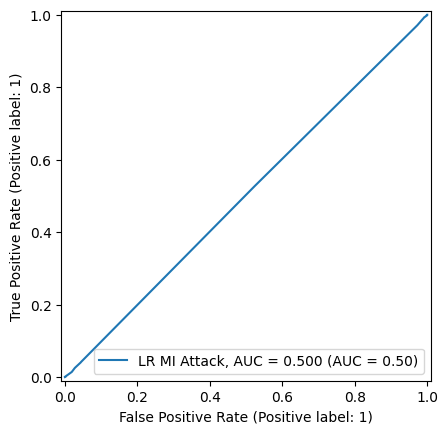

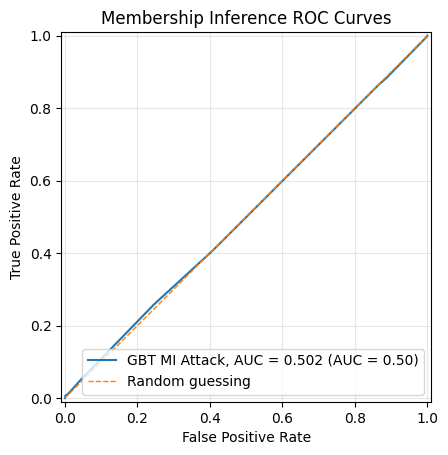

In [9]:
# ── Cell 8: Membership Inference AUC for LR and GBT ──────────────────────────

from sklearn.metrics import roc_auc_score, RocCurveDisplay

def attack_target_model(model_name, target_model, mi_pipeline):
    """
    Applies the trained shadow-model meta-classifier to the real target model.

    Members = records from the target model's training set
    Non-members = records from the target model's test set
    Feature used by attacker = target model's max confidence score
    """

    meta_clf = mi_pipeline["meta_clf"]

    # Confidence scores from target model
    conf_train = target_model.predict_proba(Xs_tr).max(axis=1).reshape(-1, 1)
    conf_test = target_model.predict_proba(Xs_te).max(axis=1).reshape(-1, 1)

    # Meta-classifier predicts membership probability
    mi_scores_train = meta_clf.predict_proba(conf_train)[:, 1]
    mi_scores_test = meta_clf.predict_proba(conf_test)[:, 1]

    # Combine members and non-members
    mi_scores = np.concatenate([mi_scores_train, mi_scores_test])
    mi_labels = np.concatenate([
        np.ones(len(mi_scores_train)),
        np.zeros(len(mi_scores_test))
    ])

    mi_auc = roc_auc_score(mi_labels, mi_scores)

    return {
        "Model": model_name,
        "MI AUC": mi_auc,
        "Member Scores": mi_scores_train,
        "Non-Member Scores": mi_scores_test,
        "All Scores": mi_scores,
        "All Labels": mi_labels
    }


# ── Attack target LR and target GBT models ────────────────────────────────────
mi_lr_result = attack_target_model(
    model_name="Logistic Regression",
    target_model=lr,
    mi_pipeline=mi_lr_shadow
)

mi_gbt_result = attack_target_model(
    model_name="Gradient Boosted Tree",
    target_model=gbt,
    mi_pipeline=mi_gbt_shadow
)

# ── Create MI summary table ──────────────────────────────────────────────────
mi_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Gradient Boosted Tree"],
    "Train AUC": [lr_train_auc, gbt_train_auc],
    "Test AUC": [lr_test_auc, gbt_test_auc],
    "Generalization Gap": [
        lr_train_auc - lr_test_auc,
        gbt_train_auc - gbt_test_auc
    ],
    "MI AUC": [
        mi_lr_result["MI AUC"],
        mi_gbt_result["MI AUC"]
    ]
})

print("Membership inference results:")
display(mi_results.round(3))

# ── Plot ROC curves for both MI attacks ───────────────────────────────────────
plt.figure(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    mi_lr_result["All Labels"],
    mi_lr_result["All Scores"],
    name=f"LR MI Attack, AUC = {mi_lr_result['MI AUC']:.3f}"
)

RocCurveDisplay.from_predictions(
    mi_gbt_result["All Labels"],
    mi_gbt_result["All Scores"],
    name=f"GBT MI Attack, AUC = {mi_gbt_result['MI AUC']:.3f}"
)

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random guessing")
plt.title("Membership Inference ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

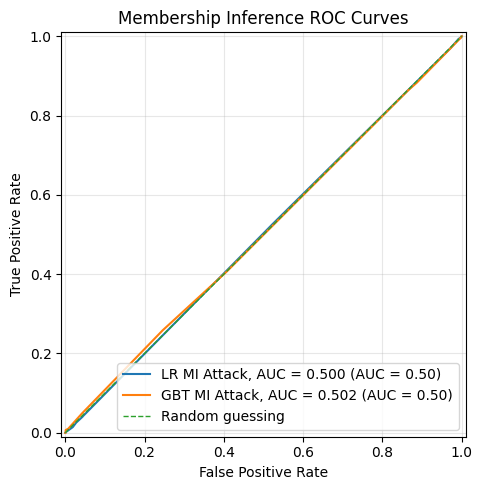

In [10]:
# ── Clean combined ROC plot for both MI attacks ───────────────────────────────

fig, ax = plt.subplots(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    mi_lr_result["All Labels"],
    mi_lr_result["All Scores"],
    name=f"LR MI Attack, AUC = {mi_lr_result['MI AUC']:.3f}",
    ax=ax
)

RocCurveDisplay.from_predictions(
    mi_gbt_result["All Labels"],
    mi_gbt_result["All Scores"],
    name=f"GBT MI Attack, AUC = {mi_gbt_result['MI AUC']:.3f}",
    ax=ax
)

ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random guessing")
ax.set_title("Membership Inference ROC Curves")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

### Membership Inference AUC Interpretation

The membership inference ROC curves show that both attacks perform almost the same as random guessing. The LR model has an MI AUC of 0.500, while the GBT model has an MI AUC of 0.502. This means the confidence-score based attacker is not able to reliably distinguish training members from non-members for either model.
The generalization gap does not strongly predict MI AUC in this experiment. The GBT model has a larger generalization gap of 0.080, while LR has a gap of -0.008, but both MI AUC values remain close to 0.50. This suggests that although overfitting can increase membership inference risk in theory, this particular shadow-model confidence attack does not produce meaningful membership leakage on this COMPAS setup.

The practical takeaway is that membership inference risk appears low here compared with the stronger risks observed in Part A and Part B. The PGD evasion and label-flip poisoning attacks created clearer fairness and security concerns than the membership inference attack.

## Part C: Confidence-Gap Histograms for LR and GBT

This section compares confidence scores for members and non-members. If training members receive systematically higher confidence scores than non-members, the model may leak membership information.

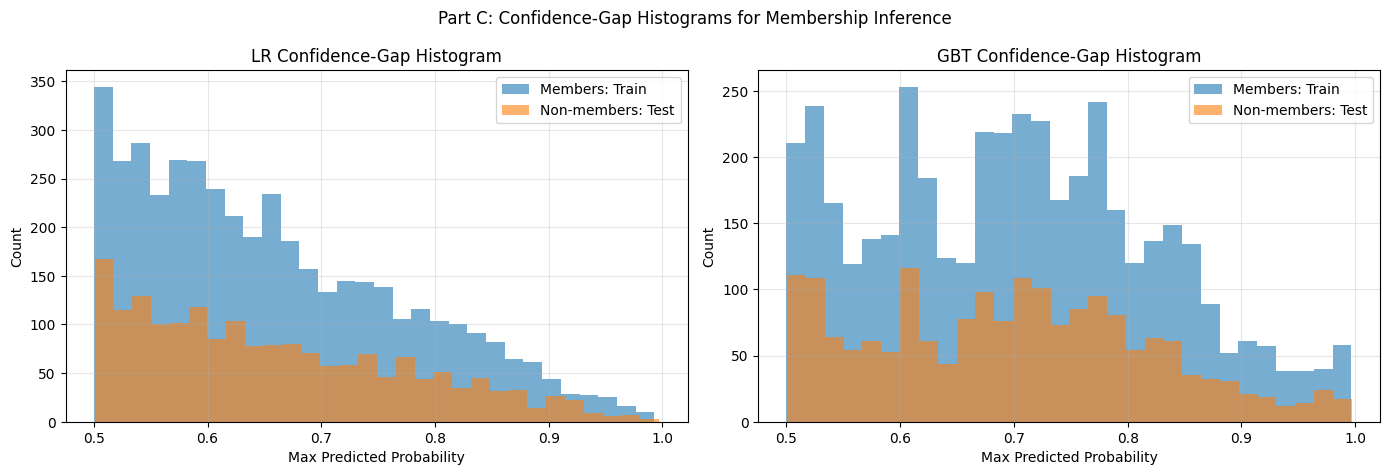

,Model,Mean Train Confidence,Mean Test Confidence,Confidence Gap
0,Logistic Regression,0.658,0.659,-0.001
1,Gradient Boosted Tree,0.702,0.697,0.005


In [11]:
# ── Cell 9: Confidence-Gap Histograms for LR and GBT ─────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

# ── LR confidence scores ─────────────────────────────────────────────────────
ax = axes[0]

lr_member_conf = lr.predict_proba(Xs_tr).max(axis=1)
lr_nonmember_conf = lr.predict_proba(Xs_te).max(axis=1)

ax.hist(lr_member_conf, bins=30, alpha=0.6, label="Members: Train")
ax.hist(lr_nonmember_conf, bins=30, alpha=0.6, label="Non-members: Test")

ax.set_title("LR Confidence-Gap Histogram")
ax.set_xlabel("Max Predicted Probability")
ax.set_ylabel("Count")
ax.legend()
ax.grid(alpha=0.3)

# ── GBT confidence scores ────────────────────────────────────────────────────
ax = axes[1]

gbt_member_conf = gbt.predict_proba(Xs_tr).max(axis=1)
gbt_nonmember_conf = gbt.predict_proba(Xs_te).max(axis=1)

ax.hist(gbt_member_conf, bins=30, alpha=0.6, label="Members: Train")
ax.hist(gbt_nonmember_conf, bins=30, alpha=0.6, label="Non-members: Test")

ax.set_title("GBT Confidence-Gap Histogram")
ax.set_xlabel("Max Predicted Probability")
ax.set_ylabel("Count")
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle("Part C: Confidence-Gap Histograms for Membership Inference")
plt.tight_layout()
plt.show()

# ── Numeric confidence-gap summary ───────────────────────────────────────────
confidence_gap_summary = pd.DataFrame({
    "Model": ["Logistic Regression", "Gradient Boosted Tree"],
    "Mean Train Confidence": [
        lr_member_conf.mean(),
        gbt_member_conf.mean()
    ],
    "Mean Test Confidence": [
        lr_nonmember_conf.mean(),
        gbt_nonmember_conf.mean()
    ],
    "Confidence Gap": [
        lr_member_conf.mean() - lr_nonmember_conf.mean(),
        gbt_member_conf.mean() - gbt_nonmember_conf.mean()
    ]
})

display(confidence_gap_summary.round(3))

### Confidence-Gap Histogram Interpretation

The confidence-gap histograms show heavy overlap between member and non-member confidence distributions for both models. For logistic regression, the mean train confidence is 0.658 and the mean test confidence is 0.659, producing a confidence gap of -0.001. This means the LR model does not assign higher confidence to training members than to test non-members.
For the gradient boosted tree model, the mean train confidence is 0.702 and the mean test confidence is 0.697, producing a small confidence gap of 0.005. Although this is slightly larger than the LR gap, it is still very small. This supports the MI AUC results, where both models were close to random guessing.

Overall, the confidence-gap evidence suggests low membership inference risk in this COMPAS setup. The attacker cannot clearly separate members from non-members using confidence scores alone.

## Part C: L2 Regularization and Membership Inference Risk

This section varies the LR regularization strength using $C \in \{0.01, 0.1, 1.0, 10.0\}$. Smaller $C$ means stronger L2 regularization. The goal is to test whether stronger regularization reduces the generalization gap and membership inference risk.

L2 regularization and membership inference results:


,C,Regularization Strength,Train AUC,Test AUC,Generalization Gap,MI AUC
0,0.01,Stronger,0.726,0.732,-0.006,0.506
1,0.10,Stronger,0.727,0.734,-0.007,0.503
2,1.00,Weaker,0.727,0.735,-0.008,0.500
3,10.00,Weaker,0.727,0.735,-0.008,0.499


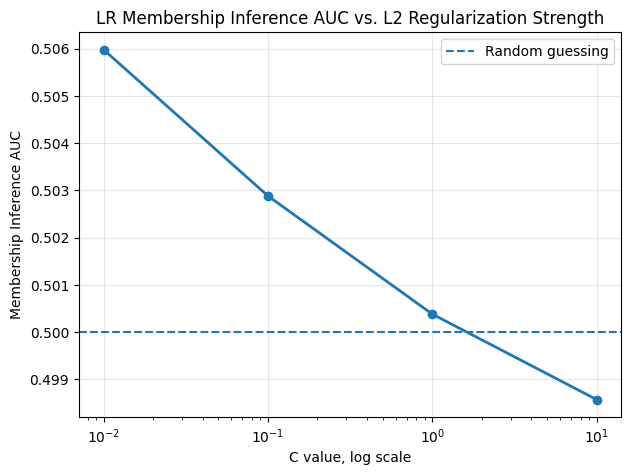

In [13]:
# ── Cell 10: L2 Regularization Experiment for LR Membership Inference ─────────

C_values = [0.01, 0.1, 1.0, 10.0]
regularization_records = []

for C in C_values:
    # Train LR target model with different L2 regularization strength
    lr_reg = LogisticRegression(
        max_iter=1000,
        C=C,
        penalty="l2",
        random_state=42
    )

    lr_reg.fit(Xs_tr, y_tr)

    # Compute train/test AUC and generalization gap
    train_auc = roc_auc_score(y_tr, lr_reg.predict_proba(Xs_tr)[:, 1])
    test_auc = roc_auc_score(y_te, lr_reg.predict_proba(Xs_te)[:, 1])
    gen_gap = train_auc - test_auc

    # Use the LR shadow meta-classifier from Cell 7
    reg_result = attack_target_model(
        model_name=f"LR C={C}",
        target_model=lr_reg,
        mi_pipeline=mi_lr_shadow
    )

    regularization_records.append({
        "C": C,
        "Regularization Strength": "Stronger" if C < 1 else "Weaker",
        "Train AUC": train_auc,
        "Test AUC": test_auc,
        "Generalization Gap": gen_gap,
        "MI AUC": reg_result["MI AUC"]
    })

df_l2_mi = pd.DataFrame(regularization_records)

print("L2 regularization and membership inference results:")
display(df_l2_mi.round(3))

# ── Plot MI AUC vs C ─────────────────────────────────────────────────────────
plt.figure(figsize=(7, 5))

plt.plot(
    df_l2_mi["C"],
    df_l2_mi["MI AUC"],
    marker="o",
    linewidth=2
)

plt.axhline(0.50, linestyle="--", linewidth=1.5, label="Random guessing")
plt.xscale("log")
plt.xlabel("C value, log scale")
plt.ylabel("Membership Inference AUC")
plt.title("LR Membership Inference AUC vs. L2 Regularization Strength")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### L2 Regularization Interpretation

The L2 regularization experiment shows that membership inference risk remains very low across all tested values of $C$. The MI AUC ranges only from 0.499 to 0.506, which is essentially random guessing. This means the attacker is not able to reliably identify whether a record was part of the LR training set.
Smaller $C$ values apply stronger regularization. At $C = 0.01$, the Test AUC is 0.732 and MI AUC is 0.506. At weaker regularization levels, such as $C = 1.0$ and $C = 10.0$, the Test AUC is slightly higher at 0.735, while MI AUC stays around 0.500. The performance difference is very small, and the privacy-risk difference is also very small.

The practical tradeoff is limited in this experiment. Stronger regularization slightly reduces predictive performance, but it does not meaningfully reduce membership inference risk because the MI AUC is already near random guessing. For this COMPAS setup, regularization is still useful as a general robustness practice, but the main security risks are more visible in the PGD evasion and label-flip poisoning results than in membership inference.

## Final Reflection: Highest-Risk Finding and Mitigation Plan

Across the three experiments, the highest-risk finding is the label-flip poisoning result from Part B. The poisoning attack is more concerning than membership inference because it creates fairness degradation while leaving AUC almost unchanged. In the poisoning experiment, the clean LR baseline AUC was 0.735, and AUC stayed close to that value across the tested poison rates. Even at higher poison rates, AUC remained within the 2 percentage point monitoring threshold. This means an AUC-only monitoring process would likely fail to detect the attack.

The proactive mitigation should be label-integrity monitoring before model training. This means checking whether label distributions change unusually by race, target class, and data source before the model is retrained. In this experiment, the strongest evidence is that the attack changed AIR while AUC stayed stable. For example, under African-American-targeted poisoning, AIR increased from the clean baseline value of 1.961 to nearly 3.0 at the highest poison rate, while AUC remained close to baseline. A proactive label audit could flag this before deployment by monitoring group-specific label rates and group-specific FPR/AIR movement.

The reactive mitigation should be attack-triggered retraining and rollback. If fairness monitoring detects that AIR moves further outside the acceptable band of $[0.80, 1.25]$, the model should be paused, the suspicious training batch should be investigated, and the model should be retrained using the last verified clean dataset. In this notebook, the clean baseline already had AIR above 1.25, so the goal is not only to return to baseline but also to prevent further degradation. A rollback would reduce the attack-driven AIR increase, especially in the African-American-targeted poisoning case where AIR moved above 2.0 and later approached 3.0.

The membership inference results were lower risk in this experiment. LR had MI AUC of 0.500 and GBT had MI AUC of 0.502, meaning the confidence-score attack performed almost like random guessing. The L2 regularization experiment also showed limited privacy tradeoff because MI AUC stayed between 0.499 and 0.506 across all tested $C$ values.

These mitigations may introduce disparate impact tradeoffs. Label-integrity monitoring can reduce unfair degradation, but it must be applied consistently across groups so that one group is not over-scrutinized more than another. Reactive rollback can prevent a poisoned model from being deployed, but if the clean baseline is already unfair, rollback alone is not enough. The responsible deployment decision should combine security monitoring with fairness governance: monitor AUC, AIR, FPR by race, label distributions, and PSI-style drift signals together rather than relying on a single aggregate metric.

## Lab Summary

This notebook extended the Lecture 05 security pipeline on the ProPublica COMPAS dataset across three applied attack settings.

| Part | Attack | Main Finding |
|---|---|---|
| Part A | PGD Evasion | Logistic regression was highly sensitive to PGD-style perturbations, with FPR rising sharply as $\epsilon$ increased. GBT was more stable under this specific PGD approximation. |
| Part B | Label-Flip Poisoning | Poisoning created a stealthy fairness risk because AUC stayed close to baseline while AIR remained outside the fairness band of $[0.80, 1.25]$. |
| Part C | Membership Inference | MI AUC stayed near random guessing for both LR and GBT, suggesting low privacy leakage under this confidence-score attack. |

The strongest overall risk was label-flip poisoning because it could degrade fairness without triggering AUC-based monitoring. The main responsible ML lesson is that security monitoring should not rely only on aggregate performance metrics. A deployment pipeline should monitor AUC, FPR by race, AIR, label integrity, and drift indicators together.